# Notebook 2

## Premier classifieur : TF-IDF + Machine Learning classique

Dans les notebooks précédents, tu as découvert le phishing et exploré le jeu de données. Maintenant, on passe aux choses sérieuses : **entraîner un modèle de machine learning** capable de classer automatiquement un email comme sûr ou phishing. 

C'est ce qu'on appelle un classifieur, un modèle qui classe une donnée dans des catégories (Par exemple, si tu souhaites savoir si une image contient un chat ou un chien, un classifieur est le modèle qui va classer chaque image soit dans la catégorie des chats, soit celle des chiens).

Mais il y a un problème : un ordinateur ne comprend pas le texte directement. Il ne comprend que les **nombres**, en binaire (0/1). Il faut donc d'abord transformer le texte en représentation numérique. C'est là qu'intervient ce qu'on appelle le **TF-IDF**.

### Ce que tu vas apprendre dans ce notebook :

1. Ce qu'est le **TF-IDF** et comment il transforme du texte en nombres.
2. Comment entraîner et comparer **3 modèles classiques** :
   - Régression Logistique
   - Naïve Bayes Multinomial
   - SVM Linéaire (Support Vector Machine)
3. Comment évaluer un modèle avec **accuracy, précision, rappel et F1-score**.
4. Comment lire une **matrice de confusion**.
5. Pourquoi la **précision** est particulièrement importante pour la détection de phishing.

## 0) Mise en place

### Changement de jeu de données

Pour les deux premiers notebooks, on utilisait le dataset **SpamAssasin** : un petit jeu de données avec des emails lisibles, parfait pour découvrir et explorer.

Pour les deux prochains notebooks (celui-ci et le suivant), on passe à un **dataset beaucoup plus grand** : **phishing_email** (~82 000 emails). Ce dataset est déjà **pré-traité** (nettoyé, ponctuation retirée, texte en minuscules, etc.), ce qui le rend moins lisible pour un humain, mais **idéal pour entraîner un modèle de machine learning**. Sa distribution est à peu près **50 % emails sûrs / 50 % phishing**, ce qui est un bon équilibre pour l'apprentissage.

Chargeons les données d'entraînement, de validation et de test.

In [ ]:
# Import des différentes libraries utilisées dans ce notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings("ignore")

# On charge les données d'entraînement, de validation et de test
train = pd.read_csv("data_training/train.csv")
val = pd.read_csv("data_training/val.csv")
test = pd.read_csv("data_training/test.csv")

print(f"Entraînement : {len(train):,} emails")
print(f"Validation : {len(val):,} emails")
print(f"Test : {len(test):,} emails")

Entraînement : 57,422 emails
Validation : 12,305 emails
Test : 12,305 emails


## 1) Qu'est-ce que le TF-IDF ?

> Avant de te l'expliquer brièvement, je te propose de lire [cet article](https://towardsdatascience.com/how-tf-idf-works-3dbf35e568f0/) (tu peux le traduire en français avec l'outil "traduire" sur Google Chrome, ou tout autre outil).

### En bref :

**TF-IDF** signifie *Term Frequency – Inverse Document Frequency* (fréquence du terme – fréquence inverse de document).

L'idée est simple :

- **TF (Term Frequency)** : combien de fois un mot apparaît dans un email donné. Plus un mot apparaît souvent dans un email, plus il est probablement important pour cet email.

- **IDF (Inverse Document Frequency)** : à quel point un mot est rare dans l'ensemble du jeu de données. Un mot qui apparaît dans tous les emails (comme \"the\") n'est pas très informatif. Un mot rare (comme \"suspended\") est beaucoup plus utile.

- **TF-IDF = TF × IDF** : le score final combine les deux. Un mot obtient un score élevé s'il est fréquent dans cet email **et** rare dans les autres.

### Exemple concret

| Mot | TF (dans un email) | IDF (dans tout le dataset) | TF-IDF |
|---|---|---|---|
| \"the\" | Élevé (très fréquent) | Très faible (présent partout) | **Faible** → peu utile |
| \"verify\" | Moyen | Élevé (assez rare) | **Élevé** → très utile |
| \"xylophone\" | Très faible | Très élevé (très rare) | **Faible** → trop rare pour être utile |

Chaque email est donc transformé en un **vecteur de nombres** (un nombre par mot du vocabulaire), et c'est ce vecteur que le modèle de machine learning va utiliser pour apprendre.

### Appliquons le TF-IDF à nos données

La bibliothèque `scikit-learn` fait tout le travail pour nous.
On lui donne du texte brut, et elle renvoie les vecteurs numériques.

In [8]:
# On crée le vectoriseur TF-IDF
# max_features=10000 : on garde les 10 000 mots les plus fréquents
# stop_words='english' : on enlève automatiquement les mots vides anglais ("the", "is", "and", etc.)
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")

# On "entraîne" le vectoriseur sur les données d'entraînement
# puis on transforme chaque ensemble
X_train = vectorizer.fit_transform(train["text"])
X_val = vectorizer.transform(val["text"])
X_test = vectorizer.transform(test["text"])

y_train = train["label"]
y_val = val["label"]
y_test = test["label"]

print(f"Taille du vocabulaire : {len(vectorizer.get_feature_names_out()):,} mots")
print(f"Forme de X_train : {X_train.shape}")
print(f"{X_train.shape[0]} emails, chacun représenté par {X_train.shape[1]} nombres")

Taille du vocabulaire : 10,000 mots
Forme de X_train : (57422, 10000)
57422 emails, chacun représenté par 10000 nombres


> Questions :
>
> - Pourquoi entraîne est entre guillemets ?
> - Puis-je utiliser ce vectoriseur sur d'autres langages que l'anglais ? Pourquoi ?

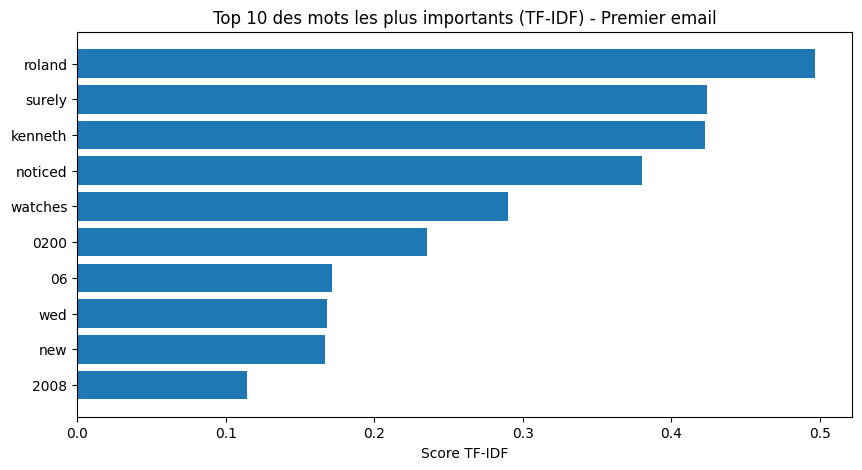

In [9]:
# Récupération des données
feature_names = vectorizer.get_feature_names_out()
first_email_tfidf = X_train[0].toarray().flatten()

# Top 10 indices
top_indices = first_email_tfidf.argsort()[-10:][::-1]

# Filtrer les valeurs non nulles
top_words = []
top_scores = []

for idx in top_indices:
    if first_email_tfidf[idx] > 0:
        top_words.append(feature_names[idx])
        top_scores.append(first_email_tfidf[idx])

# Graphique
plt.figure(figsize=(10, 5))
plt.barh(top_words[::-1], top_scores[::-1])  # inversé pour avoir le plus grand en haut
plt.xlabel("Score TF-IDF")
plt.title("Top 10 des mots les plus importants (TF-IDF) - Premier email")

plt.show()

## 2) Les métriques d'évaluation

Avant d'entraîner nos modèles, comprenons comment on va mesurer leur performance. On va se contenter des métriques d'évaluations habituels pour ce problème :

| Métrique | Définition simple | Question à laquelle elle répond |
|---|---|---|
| **Accuracy** | % de prédictions correctes | \"Le modèle se trompe-t-il souvent ?\" |
| **Précision** | Parmi les emails signalés \"phishing\", combien le sont vraiment ? | \"Quand le modèle prédit un mail de phishing, a-t-il raison ?\" |
| **Rappel** | Parmi les vrais phishing, combien ont été détectés ? | \"Le modèle rate-t-il beaucoup de phishing ?\" |
| **F1-score** | Moyenne harmonique de précision et rappel | \"Bon équilibre entre précision et rappel ?\" |

> Je te propose de te familiariser avec ces notions avec [cet article](https://labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score).

### Pourquoi la précision est cruciale ici ?

Rappelle-toi le Notebook (partie 0) : un **faux positif** (email sûr signalé comme phishing) signifie qu'un message légitime est bloqué. Une haute **précision** signifie peu de faux positifs.

Un haut **rappel** signifie que le modèle attrape la plupart des vrais phishing. L'idéal est d'avoir les deux élevés !

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def evaluate_model(name, model, X, y_true):
    """ Évalue un modèle et affiche les métriques. """
    # On prédit les étiquettes avec le modèle
    y_pred = model.predict(X)
    
    # Calcul des métriques
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Affichage des résultats
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Précision : {prec:.4f}  ({prec*100:.1f}%)")
    print(f"  Rappel    : {rec:.4f}  ({rec*100:.1f}%)")
    print(f"  F1-score  : {f1:.4f}  ({f1*100:.1f}%)")
    
    return {"nom": name, "accuracy": acc, "precision": prec, "rappel": rec, "f1": f1, "y_pred": y_pred}

## 3) Modèle n°1 : Régression Logistique

> Tu peux trouver plus d'informations sur ce modèle [ici](https://medium.com/tell-ia/la-r%C3%A9gression-logistique-expliqu%C3%A9e-%C3%A0-ma-grand-m%C3%A8re-52a2ab30788). N'hésite pas à notez un résumé de chaque modèle dans ton rapport avant de continuer dans ce notebook. Cela te permettra de mieux comprendre la suite.

Malgré son nom, la **régression logistique** est un modèle de **classification** (pas de régression !). C'est-à-dire que l'on souhaite classifier, et non pas estimer une valeur numérique. C'est l'un des modèles les plus simples et les plus utilisés.

### Comment ça marche (très simplifié) :

Le modèle attribue un **poids** à chaque mot. Les mots typiques du phishing (comme \"verify\", \"urgent\") reçoivent des poids positifs. Les mots typiques des emails sûrs reçoivent des poids négatifs. Pour classer un nouvel email, il additionne les poids de tous ses mots et décide : si la somme est positive = phishing, sinon = sûr.

In [11]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

results_lr = evaluate_model("Régression Logistique", model_lr, X_val, y_val)


  Régression Logistique
  Accuracy  : 0.9820  (98.2%)
  Précision : 0.9787  (97.9%)
  Rappel    : 0.9871  (98.7%)
  F1-score  : 0.9829  (98.3%)


### Quels mots sont les plus importants pour ce modèle ?

Regardons les mots avec les poids les plus forts (indicateurs de phishing)
et les plus faibles (indicateurs de sûr).

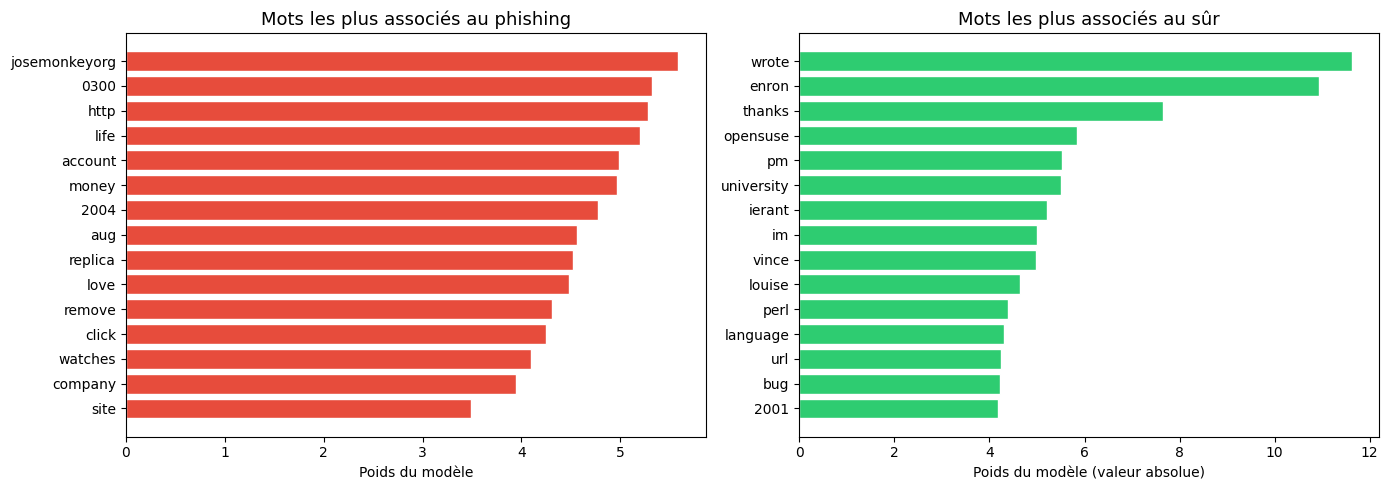

In [13]:
coefficients = model_lr.coef_[0]
top_phishing_idx = coefficients.argsort()[-15:][::-1]
top_safe_idx = coefficients.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mots phishing
words_ph = [feature_names[i] for i in reversed(top_phishing_idx)]
weights_ph = [coefficients[i] for i in reversed(top_phishing_idx)]
axes[0].barh(words_ph, weights_ph, color="#e74c3c", edgecolor="white")
axes[0].set_title("Mots les plus associés au phishing", fontsize=13)
axes[0].set_xlabel("Poids du modèle")

# Mots sûrs
words_sf = [feature_names[i] for i in reversed(top_safe_idx)]
weights_sf = [abs(coefficients[i]) for i in reversed(top_safe_idx)]
axes[1].barh(words_sf, weights_sf, color="#2ecc71", edgecolor="white")
axes[1].set_title("Mots les plus associés au sûr", fontsize=13)
axes[1].set_xlabel("Poids du modèle (valeur absolue)")

plt.tight_layout()
plt.show()

## 4) Modèle n°2 : Naïve Bayes Multinomial

> Tu peux trouver plus d'informations sur ce modèle [ici](https://medium.com/@thommaskevin/tinyml-multinominal-naive-bayes-text-classifier-d5df9bccbd32). Ce modèle est déja un peu plus complexe, n'hésite pas à t'aider de ChatGPT pour comprendre comment il fonctionne.

Le **Naïve Bayes** est un modèle basé sur les probabilités.

### Comment ça marche (simplifié) :

Pour chaque mot, le modèle calcule la probabilité qu'il apparaisse dans un email de phishing vs. un email sûr. Pour classer un nouvel email, il multiplie les probabilités de tous les mots présents et choisit la classe la plus probable.

On l'appelle \"naïve\" parce qu'il suppose que les mots sont **indépendants** les uns des autres (ce qui n'est pas vrai en réalité, mais ça marche quand même étonnamment bien !).

In [18]:
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

results_nb = evaluate_model("Naïve Bayes Multinomial", model_nb, X_val, y_val)


  Naïve Bayes Multinomial
  Accuracy  : 0.9698  (97.0%)
  Précision : 0.9829  (98.3%)
  Rappel    : 0.9589  (95.9%)
  F1-score  : 0.9708  (97.1%)


> Que constates-tu ? Ce modèle est-il meilleur que la régression linéaire ?

## 5) Modèle n°3 : SVM Linéaire

> Tu peux trouver plus d'informations sur ce modèle [ici](https://blent.ai/blog/a/svm-support-vector-machine).

Le **SVM** (Support Vector Machine) est un modèle qui cherche la meilleure \"frontière\" pour séparer les deux classes.

### Comment ça marche (simplifié) :

Imagine que chaque email est un point dans un espace à 10 000 dimensions (une dimension par mot). Le SVM trace une \"ligne\" (un hyperplan pour être précis) qui sépare au mieux les points \"sûr\" des points \"phishing\", en maximisant la marge entre les deux groupes.

In [19]:
model_svm = LinearSVC(max_iter=2000, random_state=42)
model_svm.fit(X_train, y_train)

results_svm = evaluate_model("SVM Linéaire", model_svm, X_val, y_val)


  SVM Linéaire
  Accuracy  : 0.9863  (98.6%)
  Précision : 0.9839  (98.4%)
  Rappel    : 0.9900  (99.0%)
  F1-score  : 0.9870  (98.7%)


> Que constates-tu ? Ce modèle est-il meilleur que les deux autres modèles ?

## 6) Comparaison des 3 modèles

Mettons les résultats côte à côte pour les comparer.

In [21]:
all_results = [results_lr, results_nb, results_svm]

comparison = pd.DataFrame({
    "Modèle": [r["nom"] for r in all_results],
    "Accuracy": [r["accuracy"] for r in all_results],
    "Précision": [r["precision"] for r in all_results],
    "Rappel": [r["rappel"] for r in all_results],
    "F1-score": [r["f1"] for r in all_results],
})

# Affichage en pourcentages
display_df = comparison.copy()
for col in ["Accuracy", "Précision", "Rappel", "F1-score"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.1f}%")

print("\n\u250c" + "\u2500"*62 + "\u2510")
print("\u2502       COMPARAISON DES MODÈLES (Validation)                   \u2502")
print("\u2514" + "\u2500"*62 + "\u2518\n")
print(display_df.to_string(index=False))


┌──────────────────────────────────────────────────────────────┐
│       COMPARAISON DES MODÈLES (Validation)                   │
└──────────────────────────────────────────────────────────────┘

                 Modèle Accuracy Précision Rappel F1-score
  Régression Logistique    98.2%     97.9%  98.7%    98.3%
Naïve Bayes Multinomial    97.0%     98.3%  95.9%    97.1%
           SVM Linéaire    98.6%     98.4%  99.0%    98.7%


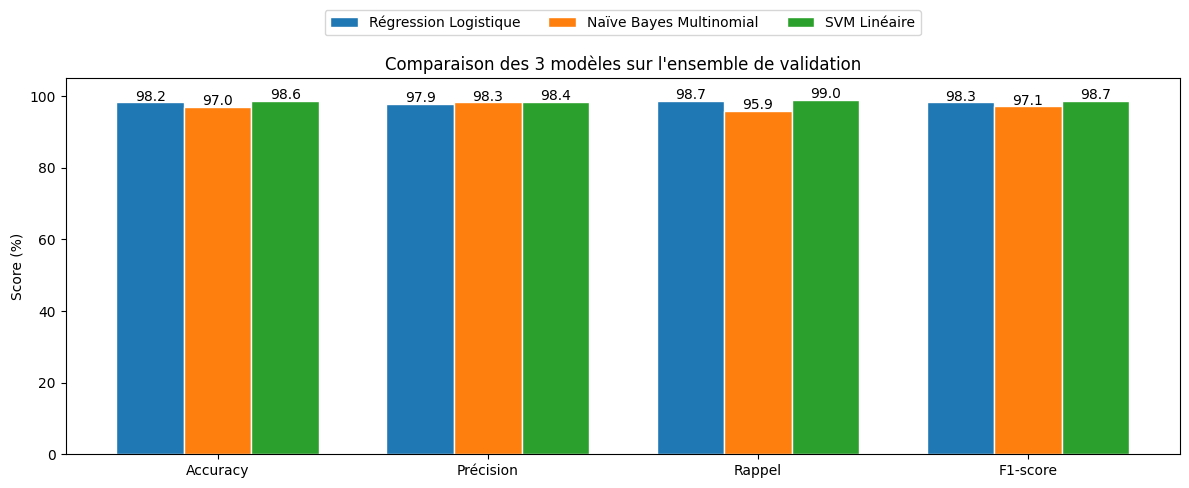

In [26]:
metrics = ["Accuracy", "Précision", "Rappel", "F1-score"]
model_names = [r["nom"] for r in all_results]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, result in enumerate(all_results):
    values = [result["accuracy"], result["precision"], result["rappel"], result["f1"]]
    bars = ax.bar(x + i*width, [v*100 for v in values], width, label=result["nom"], edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val*100:.1f}", ha="center", fontsize=10)

ax.set_ylabel("Score (%)")
ax.set_title("Comparaison des 3 modèles sur l'ensemble de validation")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 105)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)

plt.tight_layout()
plt.show()

## 7) Matrice de confusion

Tu as pu le voir dans l'article sur les métriques d'évaluations, la matrice de confusion montre **exactement où** le modèle se trompe. Affichons-la pour chacun des 3 modèles.

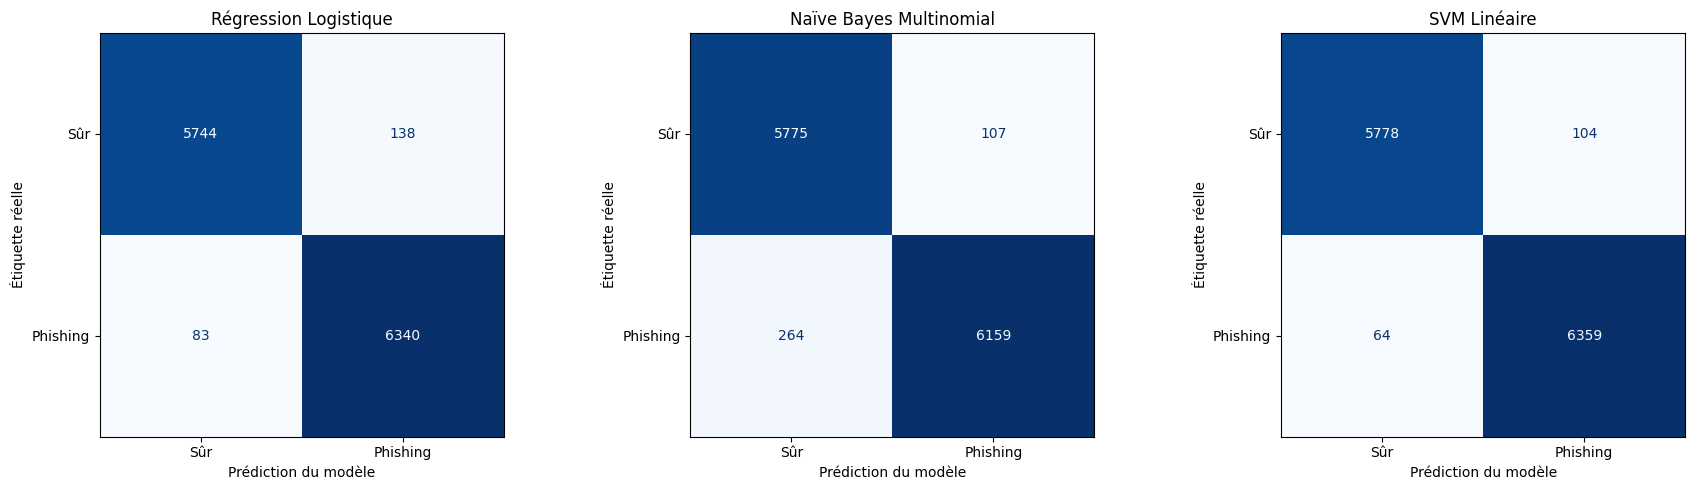

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, result in zip(axes, all_results):
    cm = confusion_matrix(y_val, result["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Sûr", "Phishing"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(result["nom"], fontsize=12)
    ax.set_xlabel("Prédiction du modèle")
    ax.set_ylabel("Étiquette réelle")

plt.tight_layout()
plt.show()

### Comment lire la matrice de confusion ?

Pour répondre à cette question, je te laisse lire [ceci](https://www.datacamp.com/fr/tutorial/what-is-a-confusion-matrix-in-machine-learning).

> Questions pour toi :
>
> - Quel modèle a le moins de **faux positifs** ?
> - Quel modèle a le moins de **faux négatifs** ?
> - Si tu devais choisir un seul modèle pour un vrai filtre email, lequel choisirais-tu ? Pourquoi ?

## 8) Évaluation finale sur l'ensemble de test

Jusqu'ici, on a évalué nos modèles sur l'ensemble de **validation**. Maintenant, choisissons le meilleur et évaluons-le une dernière fois
sur l'ensemble de **test** (qu'il n'a jamais vu). C'est l'équivalent de l'examen final !

In [28]:
# Trouvons le meilleur modèle selon le F1-score
best_idx = max(range(len(all_results)), key=lambda i: all_results[i]["f1"])
best_name = all_results[best_idx]["nom"]
best_model = [model_lr, model_nb, model_svm][best_idx]

print(f"Meilleur modèle (selon le F1 sur la validation) : {best_name}")
print(f"\n\u2500\u2500\u2500 évaluation finale sur l'ensemble de TEST \u2500\u2500\u2500")

results_test = evaluate_model(f"{best_name} (TEST)", best_model, X_test, y_test)

Meilleur modèle (selon le F1 sur la validation) : SVM Linéaire

─── évaluation finale sur l'ensemble de TEST ───

  SVM Linéaire (TEST)
  Accuracy  : 0.9894  (98.9%)
  Précision : 0.9885  (98.9%)
  Rappel    : 0.9913  (99.1%)
  F1-score  : 0.9899  (99.0%)


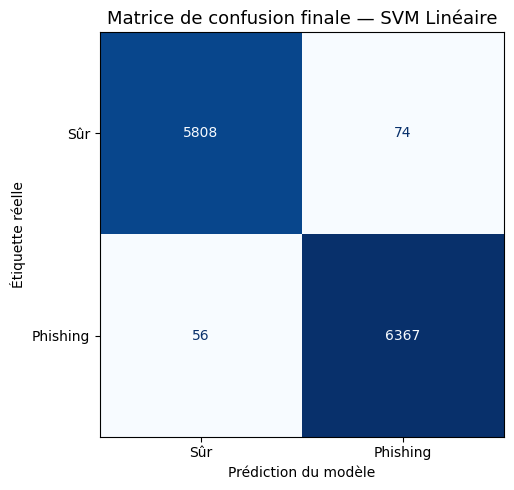


Rapport de classification détaillé :

              precision    recall  f1-score   support

         Sûr       0.99      0.99      0.99      5882
    Phishing       0.99      0.99      0.99      6423

    accuracy                           0.99     12305
   macro avg       0.99      0.99      0.99     12305
weighted avg       0.99      0.99      0.99     12305



In [29]:
# Matrice de confusion finale
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, results_test["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Sûr", "Phishing"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion finale \u2014 {best_name}", fontsize=13)
ax.set_xlabel("Prédiction du modèle")
ax.set_ylabel("Étiquette réelle")
plt.tight_layout()
plt.show()

print(f"\nRapport de classification détaillé :\n")
print(classification_report(y_test, results_test["y_pred"], target_names=["Sûr", "Phishing"]))

## 9) Testons avec nos propres emails !

Amusons-nous un peu : écris tes propres emails (en anglais) et vois ce que le modèle prédit.

In [38]:
# NOTE: Tu peux modifier ces emails et en ajouter d'autres si tu veux !

my_emails = [
    "URGENT: Your account has been compromised! Click here immediately to verify your identity or your account will be suspended.",
    "Hi team, just a reminder about tomorrow's meeting at 2pm. Please bring your laptops.",
    "Congratulations! You've won a $500 Amazon gift card. Click the link below to claim your prize now.",
    "Dear customer, your package has been shipped and will arrive on Thursday. Track your order here.",
]

X_custom = vectorizer.transform(my_emails)
predictions = best_model.predict(X_custom)

print("Prédictions du modèle :\n")
for email, pred in zip(my_emails, predictions):
    label = "PHISHING" if pred == 1 else "SÛR"
    preview = email[:120] + ("..." if len(email) > 120 else "")
    print(f"  {label:15s}  \u2502  {preview}")

Prédictions du modèle :

  PHISHING         │  URGENT: Your account has been compromised! Click here immediately to verify your identity or your account will be suspen...
  SÛR              │  Hi team, just a reminder about tomorrow's meeting at 2pm. Please bring your laptops.
  PHISHING         │  Congratulations! You've won a $500 Amazon gift card. Click the link below to claim your prize now.
  PHISHING         │  Dear customer, your package has been shipped and will arrive on Thursday. Track your order here.


> Question : Est-ce que tu vois quelque chose d'anormal dans les emails que tu essaies ? Tout tes emails sont-ils correctement classés ?

## 10) Réflexion et conclusion

Voici quelques questions supplémentaires qui peuvent aggrémenter ton rapport :

1. **Quel modèle a le mieux fonctionné ?** Étais-tu surpris ?
2. **Quelles sont les limites du TF-IDF ?** Peut-il comprendre le sens d'une phrase, ou seulement compter des mots ?
3. **Si un email dit \"Your account is NOT suspended\",** le modèle TF-IDF comprendrait-il la négation ? Pourquoi ?
4. **Comment pourrait-on faire mieux ?**

## Résumé

Dans ce notebook, tu as :

- Compris comment le **TF-IDF** transforme du texte en vecteurs numériques.
- Entraîné **3 modèles classiques** : Régression Logistique, Naïve Bayes, et SVM.
- Appris à évaluer avec **accuracy, précision, rappel et F1-score**.
- Lu des **matrices de confusion** pour comprendre les erreurs.
- Découvert les **mots les plus importants** pour le modèle.
- Testé le modèle avec tes **propres emails**.

Le TF-IDF + ML classique fonctionne déjà très bien ! Mais il a une limitation : il traite chaque mot **indépendamment**, sans comprendre le contexte ni l'ordre des mots.

**À suivre :** Dans le *Notebook (partie 3)*, nous utiliserons un **Transformer** (DistilBERT) qui comprend le contexte des mots et peut potentiellement faire encore mieux ! Tu le sais peut-être déja, mais les transformers sont les architectures à la base des modèles que tu utilises quotidiennement (ChatGPT, Claude, Gemini, ...).